In [1]:
from torchvision import models
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import json
import timm
from tqdm import tqdm
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0]
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [3]:
PROJECT_ROOT = get_project_root()
CLASSES_DIR = PROJECT_ROOT / "Classes"
DATA_DIR = PROJECT_ROOT / "Data"

device = get_device()

Using device: cuda


In [4]:
SPLIT_DIR = DATA_DIR / "splits"

train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

#### 3rd Model - Swin Transformer Tiny

##### Build Data Loaders

In [5]:
train_tfms_mild = get_train_tfms_mild()
train_tfms_strong = get_train_tfms_strong()
val_tfms = get_val_tfms()

In [6]:
CLASSES = sorted(train["class"].unique().tolist())

In [7]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x7feeee0fd750>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x7feeee430410>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x7feeee432210>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x7feeee3e9c90>}

In [8]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [9]:
criterion = nn.CrossEntropyLoss()

In [11]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "swin_tiny_best.pth"

In [12]:
# ============================================================
# SWIN TINY -- MODEL
# ============================================================
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=len(CLASSES))
model = model.to(device)

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

In [13]:
# ============================================================
# SWIN TINY -- IMPROVED SETUP
# ============================================================

# 1. Label smoothing helps with overconfidence on background cues
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [18]:
# ============================================================
# SWIN TINY -- PHASE 1: TRAIN HEAD ONLY
# ============================================================
print("\n--- Swin Tiny Phase 1: Training head only ---")
for param in model.parameters():
    param.requires_grad = False
for param in model.head.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.head.parameters(), lr=1e-3, weight_decay=0.01)
HEAD_EPOCHS = 3

for epoch in range(HEAD_EPOCHS):
    model.train()
    running_loss, correct, total_n = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Swin Phase1 {epoch+1}/{HEAD_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_n += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    print(f"  Phase1 Epoch {epoch+1} - Loss: {running_loss/len(train_loader.dataset):.4f}, Acc: {correct/total_n:.4f}")



--- Swin Tiny Phase 1: Training head only ---


Swin Phase1 1/3: 100%|██████████| 1205/1205 [09:17<00:00,  2.16it/s]


  Phase1 Epoch 1 - Loss: 0.8177, Acc: 0.6843


Swin Phase1 2/3: 100%|██████████| 1205/1205 [02:10<00:00,  9.23it/s]


  Phase1 Epoch 2 - Loss: 0.7849, Acc: 0.7099


Swin Phase1 3/3: 100%|██████████| 1205/1205 [02:10<00:00,  9.23it/s]

  Phase1 Epoch 3 - Loss: 0.7790, Acc: 0.7140


In [20]:
# ============================================================
# SWIN TINY -- PHASE 2: FULL FINE-TUNING (improved)
# ============================================================
print("\n--- Swin Tiny Phase 2: Full fine-tuning ---")
for param in model.parameters():
    param.requires_grad = True

param_groups = [
    {"params": model.head.parameters(), "lr": 1e-4},
    {"params": [p for n, p in model.named_parameters() if "head" not in n], "lr": 1e-5},
]
optimizer = torch.optim.AdamW(param_groups, weight_decay=0.01)

num_epochs = 20
warmup_epochs = 2
scheduler = SequentialLR(optimizer,
    schedulers=[LinearLR(optimizer, start_factor=0.01, total_iters=warmup_epochs),
                CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs)],
    milestones=[warmup_epochs])

best_acc = 0.0
patience = 7  
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Swin Epoch {epoch+1}/{num_epochs} Train"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_loss = train_loss / len(train_loader.dataset)
    train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Swin Epoch {epoch+1}/{num_epochs} Val"):
            images, labels = images.to(device), labels.to(device)
            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_loss / len(val_loader.dataset)
    val_acc = val_correct / val_total

    print(f"\nSwin Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  Saved best model (Val Acc: {best_acc:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{patience} epochs")
        if epochs_no_improve >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    scheduler.step()


--- Swin Tiny Phase 2: Full fine-tuning ---


Swin Epoch 1/20 Val: 100%|██████████| 151/151 [00:16<00:00,  9.22it/s]



Swin Epoch 1/20
Train Loss: 0.7658, Train Acc: 0.7254
Val Loss: 0.7045, Val Acc: 0.7690
  Saved best model (Val Acc: 0.7690)


Swin Epoch 2/20 Val: 100%|██████████| 151/151 [00:16<00:00,  9.23it/s]



Swin Epoch 2/20
Train Loss: 0.6985, Train Acc: 0.7664
Val Loss: 0.6001, Val Acc: 0.8252


...


Swin Epoch 18/20
Train Loss: 0.4148, Train Acc: 0.9388
Val Loss: 0.4654, Val Acc: 0.9085
  No improvement for 1/7 epochs


Swin Epoch 19/20 Val: 100%|██████████| 151/151 [00:17<00:00,  8.72it/s]



Swin Epoch 19/20
Train Loss: 0.4135, Train Acc: 0.9395
Val Loss: 0.4650, Val Acc: 0.9091
  Saved best model (Val Acc: 0.9091)


Swin Epoch 20/20 Val: 100%|██████████| 151/151 [00:16<00:00,  9.24it/s]


Swin Epoch 20/20
Train Loss: 0.4147, Train Acc: 0.9395
Val Loss: 0.4646, Val Acc: 0.9087
  No improvement for 1/7 epochs


Swin Testing:   1%|▏         | 2/151 [00:00<00:33,  4.40it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fef06a98d60>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
    if w.is_alive():
Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7fef06a98d60> 
 Traceback (most recent call last):
   File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
      self._shutdown_workers() 
^  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1462, in _shutdown_workers
^    ^if w.is_alive():^
^ ^ ^ ^ ^ ^ ^ ^^
^  File "/opt/conda/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
Swin Testing:   2%|▏         | 3/151 [00:00


TEST RESULTS: Swin Tiny
Overall Accuracy:  0.9068
                      precision    recall  f1-score   support

conditionally_edible     0.9103    0.9165    0.9134      1605
              edible     0.8955    0.8804    0.8879      1606
               toxic     0.9143    0.9234    0.9188      1606

            accuracy                         0.9068      4817
           macro avg     0.9067    0.9068    0.9067      4817
        weighted avg     0.9067    0.9068    0.9067      4817



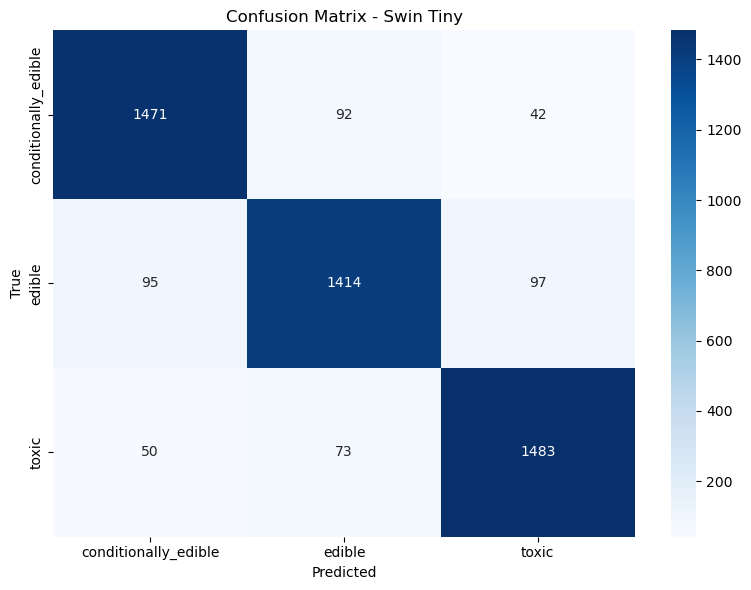


Safety-Critical Recall:


In [ ]:
# ============================================================
# SWIN TINY -- TEST EVALUATION
# ============================================================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Swin Testing"):
        images, labels = images.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\n{'='*60}")
print(f"TEST RESULTS: Swin Tiny")
print(f"{'='*60}")
print(f"Overall Accuracy:  {(all_preds == all_labels).mean():.4f}")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - Swin Tiny')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'Graphs' / 'Swin_tiny_baseline' / 'swin_tiny_confusion_matrix.png', dpi=150)
plt.show()

print("\nSafety-Critical Recall:")
for cls in ['poisonous', 'deadly']:
    if cls in CLASSES:
        i = CLASSES.index(cls)
        rec = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
        print(f"  {cls:20s} recall = {rec:.4f}  ({cm[i,i]}/{cm[i].sum()})")

In [22]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

def reshape_transform(tensor, height=7, width=7):
    result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

target_layers = [model.layers[-1].blocks[-1].norm2]
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1.0/s for s in IMAGENET_STD]
)

=== Grad-CAM on CORRECT predictions ===


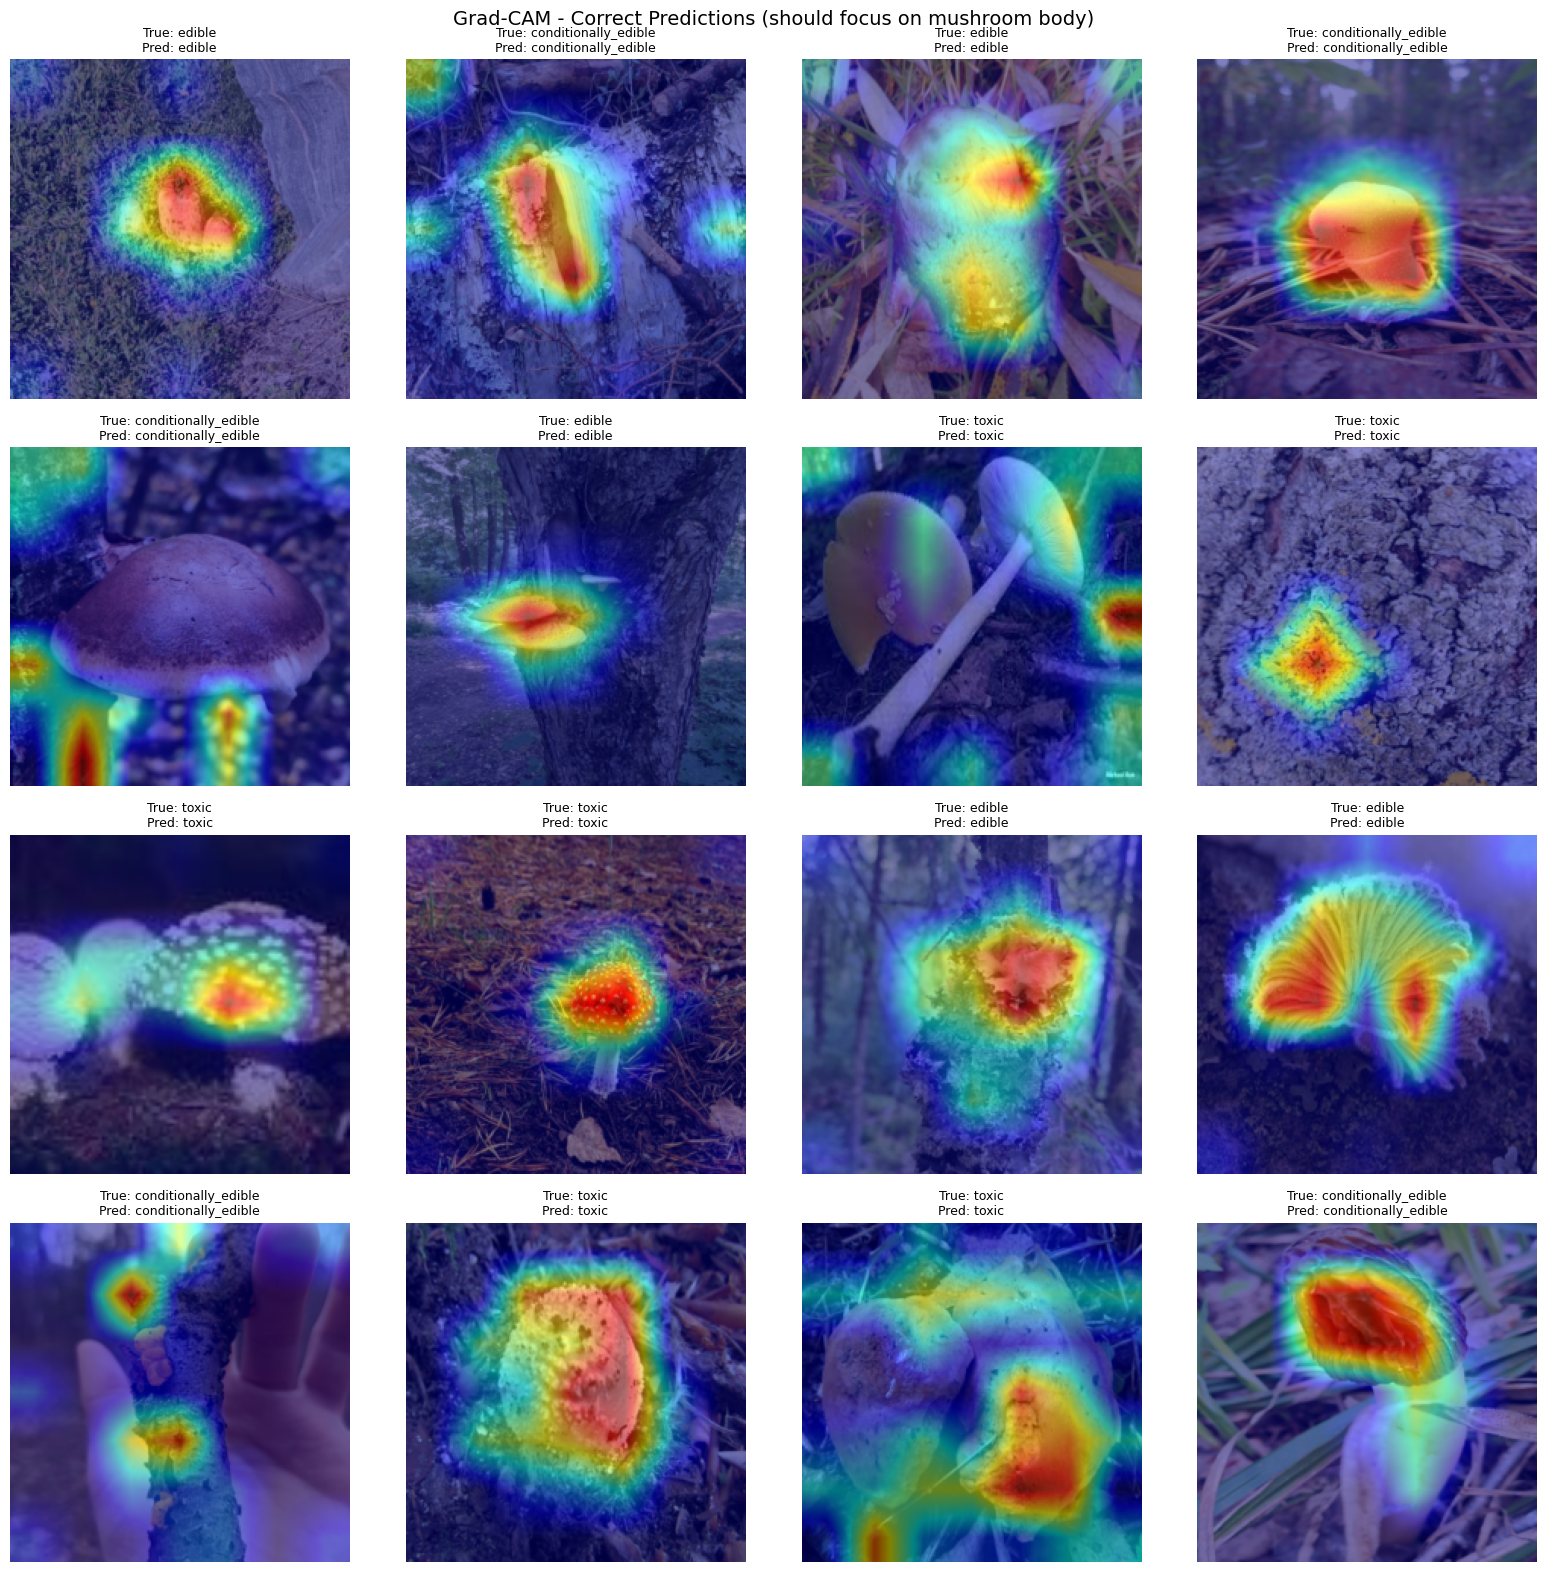

In [ ]:
# --- Visualize correct predictions (sanity check: model looking at mushroom?) ---
print("=== Grad-CAM on CORRECT predictions ===")
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

shown = 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, predicted = outputs.max(1)
    correct_mask = predicted.eq(labels)

    for i in range(images.size(0)):
        if not correct_mask[i]:
            continue
        if shown >= 16:
            break

        input_tensor = images[i].unsqueeze(0)
        target_class = labels[i].item()

        grayscale_cam = cam(input_tensor=input_tensor,
                            targets=[ClassifierOutputTarget(target_class)])[0]

        rgb_img = inv_normalize(images[i].cpu()).permute(1, 2, 0).numpy()
        rgb_img = np.clip(rgb_img, 0, 1)

        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        row, col = divmod(shown, 4)
        axes[row, col].imshow(cam_image)
        axes[row, col].set_title(f"True: {CLASSES[target_class]}\nPred: {CLASSES[predicted[i].item()]}",
                                  fontsize=9)
        axes[row, col].axis('off')
        shown += 1

    if shown >= 16:
        break

plt.suptitle("Grad-CAM - Correct Predictions (should focus on mushroom body)", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'Graphs' / 'Swin_tiny_fine_tune' / 'swin_tiny_gradcam_correct.png', dpi=150)
plt.show()


=== Grad-CAM on MISCLASSIFIED predictions ===


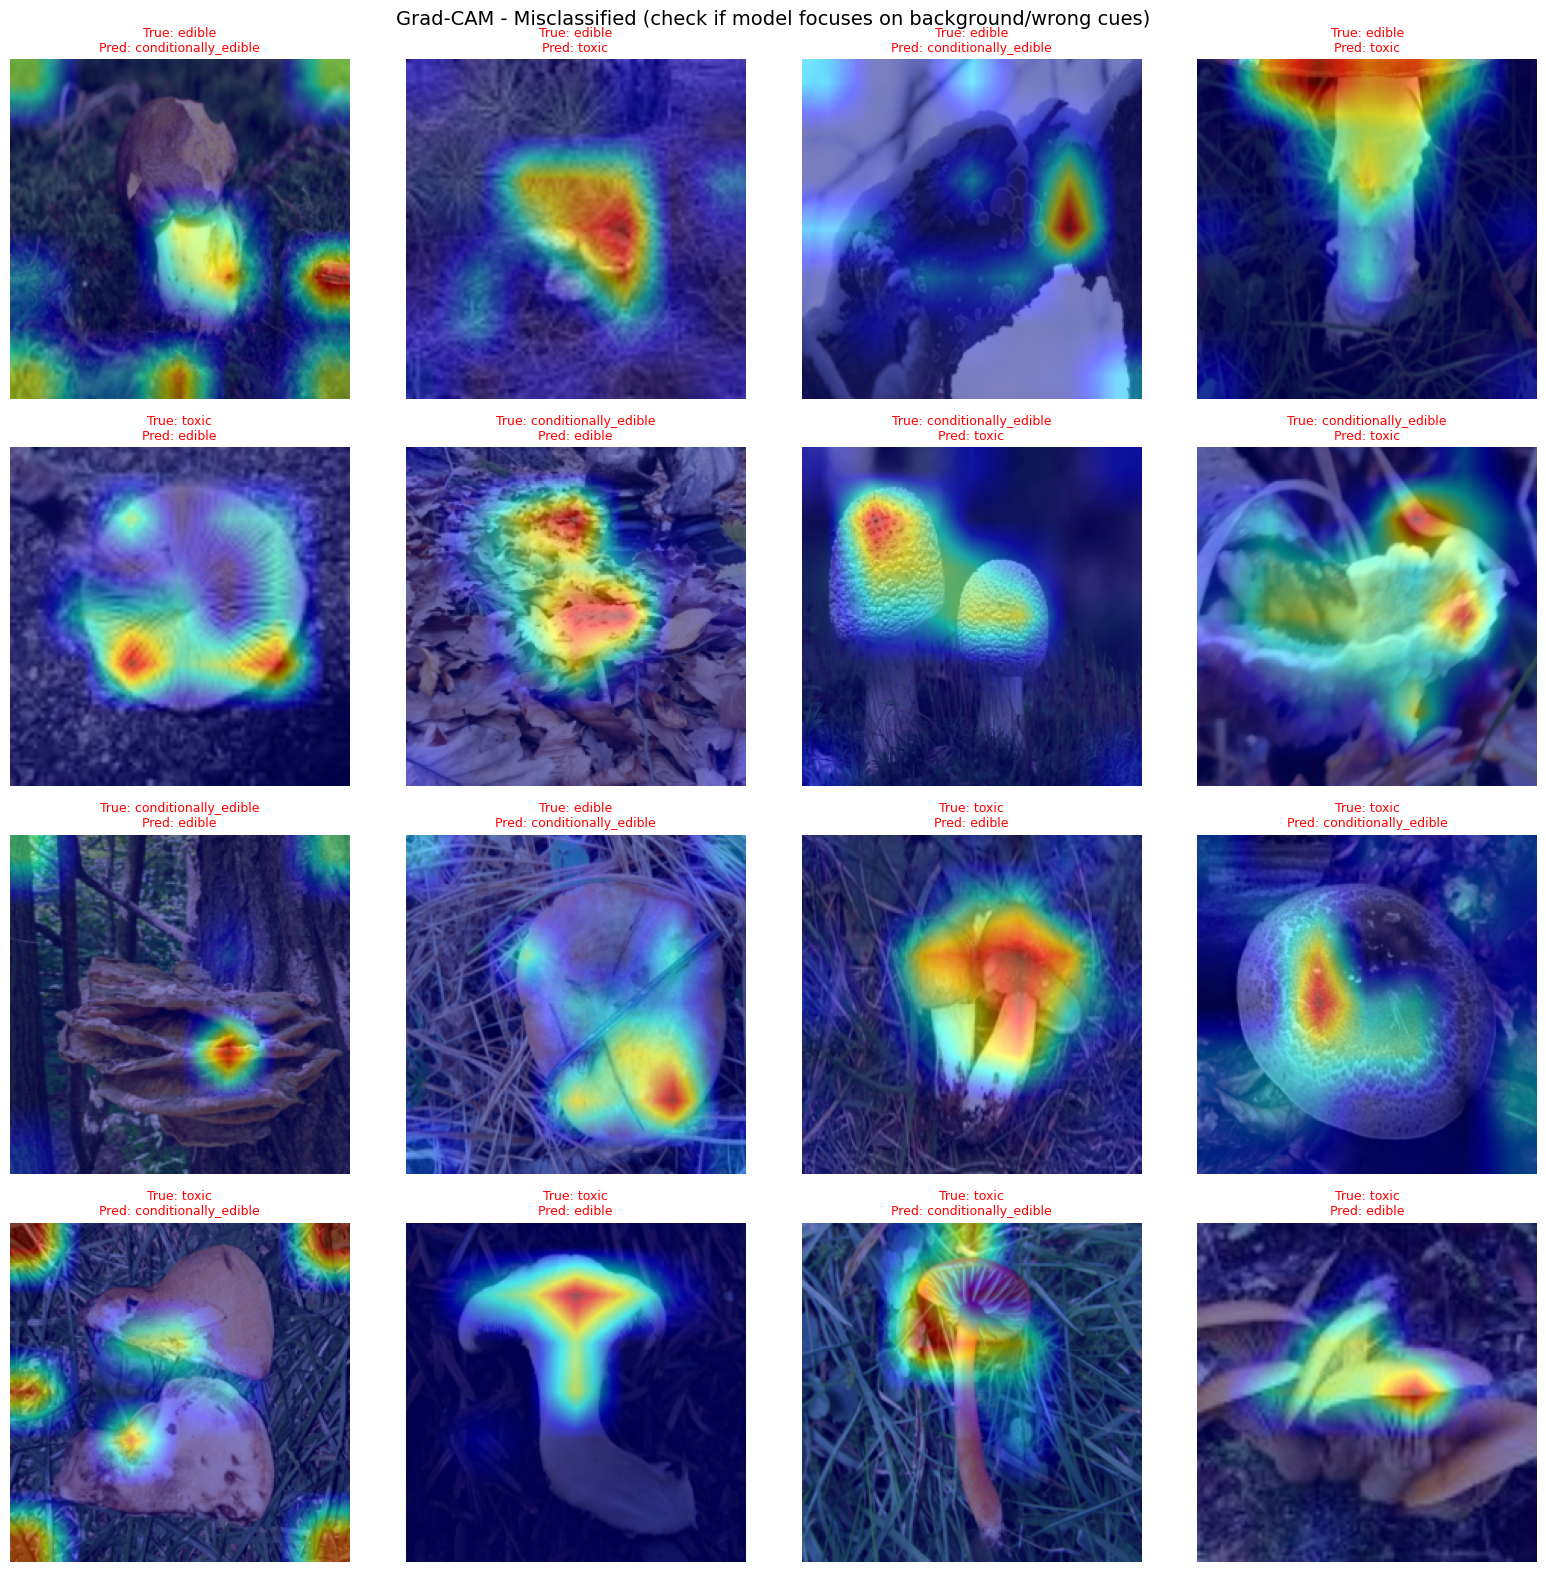

In [ ]:
# --- Visualize MISCLASSIFIED predictions (where is the model confused?) ---
print("\n=== Grad-CAM on MISCLASSIFIED predictions ===")
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

shown = 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    with torch.no_grad():
        outputs = model(images)
        _, predicted = outputs.max(1)
    wrong_mask = ~predicted.eq(labels)

    for i in range(images.size(0)):
        if not wrong_mask[i]:
            continue
        if shown >= 16:
            break

        input_tensor = images[i].unsqueeze(0)
        true_class = labels[i].item()
        pred_class = predicted[i].item()

        grayscale_cam = cam(input_tensor=input_tensor,
                            targets=[ClassifierOutputTarget(pred_class)])[0]

        rgb_img = inv_normalize(images[i].cpu()).permute(1, 2, 0).numpy()
        rgb_img = np.clip(rgb_img, 0, 1)

        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        row, col = divmod(shown, 4)
        axes[row, col].imshow(cam_image)
        axes[row, col].set_title(f"True: {CLASSES[true_class]}\nPred: {CLASSES[pred_class]}",
                                  fontsize=9, color='red')
        axes[row, col].axis('off')
        shown += 1

    if shown >= 16:
        break

if shown < 16:
    for idx in range(shown, 16):
        row, col = divmod(idx, 4)
        axes[row, col].axis('off')

plt.suptitle("Grad-CAM - Misclassified (check if model focuses on background/wrong cues)", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'Graphs' / 'Swin_tiny_fine_tune' / 'swin_tiny_gradcam_misclassified.png', dpi=150)
plt.show()


=== Grad-CAM on poisonous/deadly samples ===


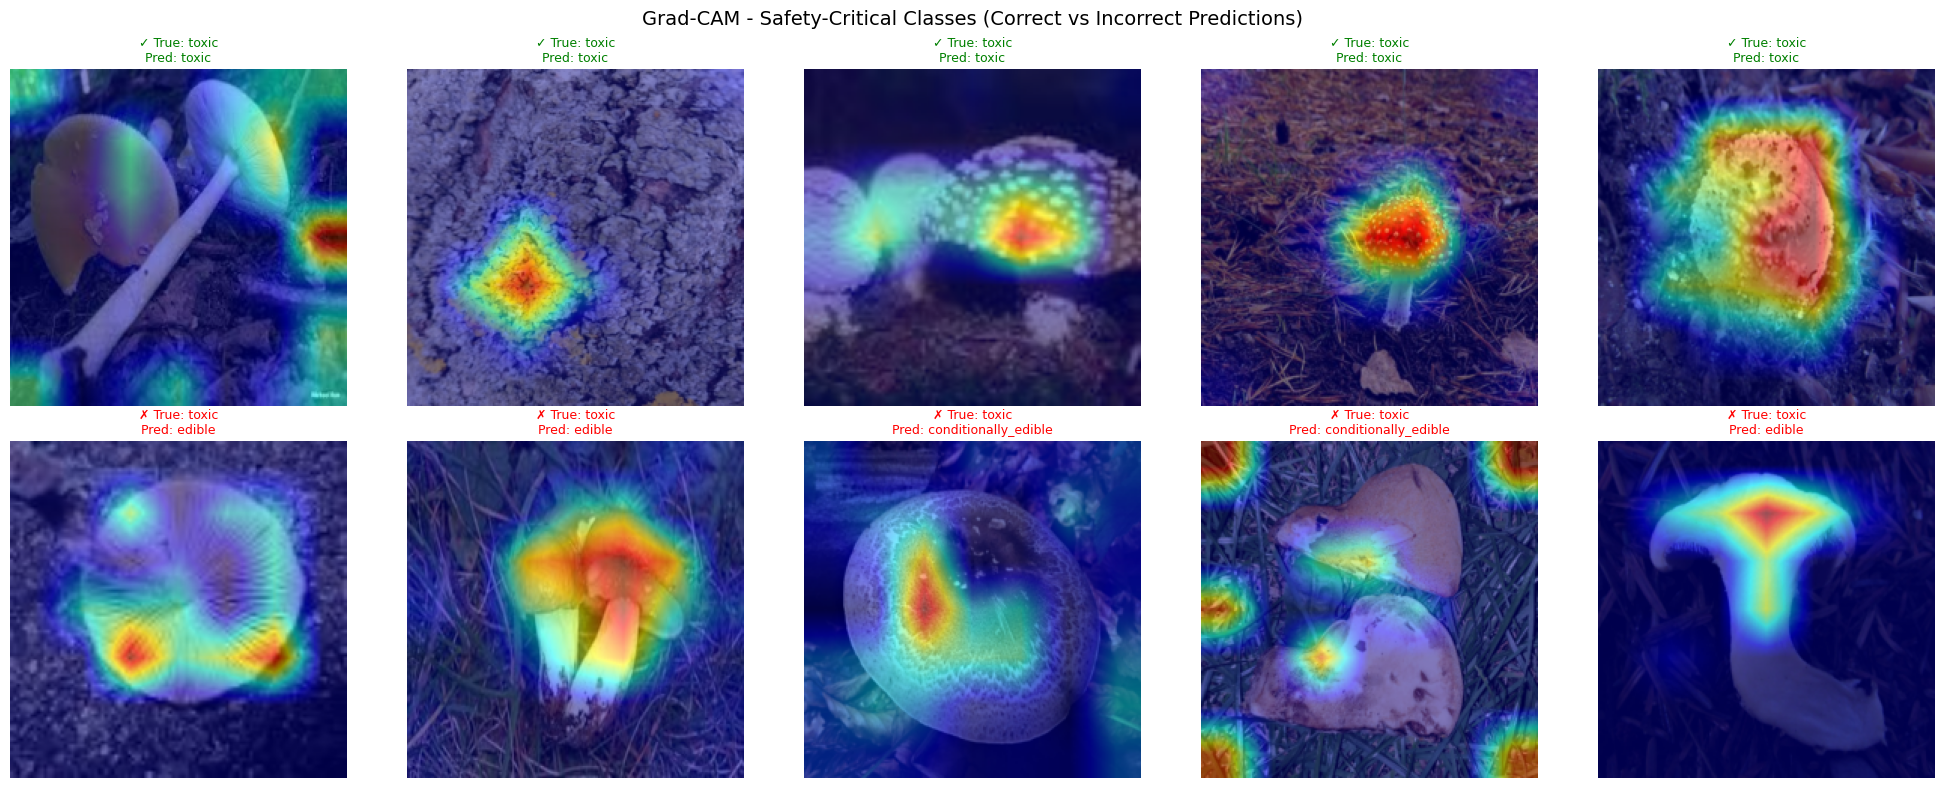

In [ ]:
# --- Safety-critical: Grad-CAM on poisonous/deadly samples ---
print("\n=== Grad-CAM on poisonous/deadly samples ===")
safety_classes = [c for c in ['poisonous', 'deadly', 'toxic'] if c in CLASSES]

# 2 rows per class (correct + incorrect), 5 columns
fig, axes = plt.subplots(len(safety_classes) * 2, 5, figsize=(20, 8 * len(safety_classes)))

for row_idx, cls_name in enumerate(safety_classes):
    cls_idx = CLASSES.index(cls_name)

    correct_examples = []
    incorrect_examples = []

    for images, labels in test_loader:
        if len(correct_examples) >= 5 and len(incorrect_examples) >= 5:
            break

        images, labels = images.to(device), labels.to(device)
        mask = labels.eq(cls_idx)

        for i in range(images.size(0)):
            if not mask[i]:
                continue
            if len(correct_examples) >= 5 and len(incorrect_examples) >= 5:
                break

            input_tensor = images[i].unsqueeze(0)
            with torch.no_grad():
                outputs = model(input_tensor)
                _, pred = outputs.max(1)
            pred_class = pred.item()

            grayscale_cam = cam(input_tensor=input_tensor,
                                targets=[ClassifierOutputTarget(pred_class)])[0]

            rgb_img = inv_normalize(images[i].cpu()).permute(1, 2, 0).numpy()
            rgb_img = np.clip(rgb_img, 0, 1)
            cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

            entry = (cam_image, cls_name, CLASSES[pred_class])

            if pred_class == cls_idx and len(correct_examples) < 5:
                correct_examples.append(entry)
            elif pred_class != cls_idx and len(incorrect_examples) < 5:
                incorrect_examples.append(entry)

    # Plot correct predictions row
    for col, (cam_image, true_cls, pred_cls) in enumerate(correct_examples):
        axes[row_idx * 2][col].imshow(cam_image)
        axes[row_idx * 2][col].set_title(f"✓ True: {true_cls}\nPred: {pred_cls}", fontsize=9, color='green')
        axes[row_idx * 2][col].axis('off')
    for col in range(len(correct_examples), 5):
        axes[row_idx * 2][col].axis('off')
    axes[row_idx * 2][0].set_ylabel(f"{cls_name}\nCORRECT", fontsize=11, color='green')

    # Plot incorrect predictions row
    for col, (cam_image, true_cls, pred_cls) in enumerate(incorrect_examples):
        axes[row_idx * 2 + 1][col].imshow(cam_image)
        axes[row_idx * 2 + 1][col].set_title(f"✗ True: {true_cls}\nPred: {pred_cls}", fontsize=9, color='red')
        axes[row_idx * 2 + 1][col].axis('off')
    for col in range(len(incorrect_examples), 5):
        axes[row_idx * 2 + 1][col].axis('off')
    axes[row_idx * 2 + 1][0].set_ylabel(f"{cls_name}\nINCORRECT", fontsize=11, color='red')

plt.suptitle("Grad-CAM - Safety-Critical Classes (Correct vs Incorrect Predictions)", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'Graphs' / 'Swin_tiny_fine_tune' / 'swin_tiny_gradcam_safety.png', dpi=150)
plt.show()

In [26]:
# --- Save ALL toxic misclassifications to disk ---
from PIL import Image as PILImage
import os

save_dir = Path("gradcam_toxic_misclassified")
save_dir.mkdir(exist_ok=True)

print("\n=== Saving all toxic misclassifications ===")
toxic_idx = CLASSES.index('toxic')
saved = 0

for images, labels in tqdm(test_loader, desc="Scanning test set"):
    images, labels = images.to(device), labels.to(device)
    mask = labels.eq(toxic_idx)

    for i in range(images.size(0)):
        if not mask[i]:
            continue

        input_tensor = images[i].unsqueeze(0)
        with torch.no_grad():
            outputs = model(input_tensor)
            _, pred = outputs.max(1)
        pred_class = pred.item()

        if pred_class == toxic_idx:
            continue  # skip correct predictions

        grayscale_cam = cam(input_tensor=input_tensor,
                            targets=[ClassifierOutputTarget(pred_class)])[0]

        rgb_img = inv_normalize(images[i].cpu()).permute(1, 2, 0).numpy()
        rgb_img = np.clip(rgb_img, 0, 1)
        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        # Save with filename showing what it was misclassified as
        pred_name = CLASSES[pred_class]
        filename = save_dir / f"{saved:04d}_true_toxic_pred_{pred_name}.png"
        PILImage.fromarray(cam_image).save(filename)
        saved += 1

print(f"\nSaved {saved} misclassified toxic images to '{save_dir}/'")
print("Browse them in JupyterHub file browser under 04_Model/gradcam_swin_toxic_misclassified/")


=== Saving all toxic misclassifications ===


Scanning test set: 100%|██████████| 151/151 [00:44<00:00,  3.36it/s]


Saved 123 misclassified toxic images to 'gradcam_toxic_misclassified/'
Browse them in JupyterHub file browser under 04_Model/gradcam_swin_toxic_misclassified/
